# Lecture 4 · Part I — Finding geodesics *by search*

### The cross-entropy method: reinforcement learning's "hello world", for geometers

In Lectures 2 our warm-ups were **supervised**: a network learned Euler's formula, then a
Calabi–Yau metric, from *labelled* data. Reinforcement learning (RL) removes the labels. An agent
**builds an object step by step** and is graded by a **reward** — a measurable proxy for the property we
want.

The most geometric first example is a **geodesic**. We will:

1. turn "find the shortest path between two points" into a search problem — build a path node by node,
   reward $=$ *minus its length*;
2. solve it with the **cross-entropy method**, the lightest RL algorithm — *sample paths, keep the
   shortest, refit, repeat* — then **sharpen** the answer with a few steps of gradient descent;
3. run it on the round sphere $S^2$ and **verify** against the closed form, length
   $\to\arccos\langle p,q\rangle$;
4. run the *same loop* on a triaxial ellipsoid, where geodesics have **no elementary formula**, and
   **certify** the result through the geodesic equation $\nabla_{\gamma'}\gamma'\approx 0$;
5. close with a small **neural policy trained by policy gradient**, the idea Part II scales up with PPO.

> **A note on honesty.** You would never *search* for a geodesic on the sphere — you would integrate the
> geodesic ODE. That is exactly why it is the perfect teaching example: we **know the answer**, so we can
> trust the method before turning it loose where no formula exists (the ellipsoid, and later, free line
> arrangements). Running theme of the lecture: **AI proposes candidates; rigorous methods dispose.**

*Self-contained and Binder-ready — every object is generated below. `Runtime → Run all`.*

## 0 · Setup

The workshop palette (teal / orange, grey for "candidates"), `float64` throughout so the closed-form
check is clean, and PyTorch for all sampling and scoring — it vectorises the whole batch of paths at once
and gives us autograd for the refinement and the neural section.

In [1]:
# %matplotlib inline
import numpy as np
import torch
import torch.nn as nn
from torch.distributions import Normal
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (enables 3d projection)

torch.set_default_dtype(torch.float64)
np.random.seed(0); torch.manual_seed(0)

TEAL, ORANGE, GREY, LTEAL = "#23373B", "#EB811B", "#9AA7AD", "#5E7E86"
plt.rcParams.update({
    "figure.dpi": 116, "savefig.dpi": 116,
    "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.edgecolor": TEAL, "axes.labelcolor": TEAL,
    "xtick.color": TEAL, "ytick.color": TEAL, "text.color": TEAL,
    "axes.titlecolor": TEAL, "figure.facecolor": "white",
})
def style2d(ax):
    ax.grid(True, color=GREY, alpha=0.25, lw=0.7)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    ax.tick_params(length=3)

print("torch", torch.__version__.split("+")[0], "| numpy", np.__version__)
print("device: cpu  |  dtype: float64")

torch 2.12.1 | numpy 2.2.6
device: cpu  |  dtype: float64


## 1 · A geodesic is the solution of an optimisation problem

On a Riemannian manifold $(M,g)$ a curve $\gamma:[0,1]\to M$ has **length** and **energy**

$$
L[\gamma]=\int_0^1 \lVert\gamma'(t)\rVert_g\,dt,
\qquad
E[\gamma]=\tfrac12\int_0^1 \lVert\gamma'(t)\rVert_g^2\,dt .
$$

A **geodesic** is a critical point of $E$; it locally minimises length and satisfies
$\;\nabla_{\gamma'}\gamma'=0\;$ (zero covariant acceleration).

**Discretise.** Replace $\gamma$ by nodes $p=x_0,x_1,\dots,x_K,x_{K+1}=q$ and, with
$\ell_i=\mathrm{dist}(x_i,x_{i+1})$, set $\;L=\sum_i \ell_i,\;\; E=\sum_i \ell_i^{\,2}.$

**Why reward energy, not length?** Length is reparametrisation-invariant, so a minimiser can *cheat* —
pile every interior node at $p$ and jump once to $q$: still length $\arccos\langle p,q\rangle$, but a
degenerate "path". Energy forbids this. By Cauchy–Schwarz $L^2\le K\,E$, **with equality iff all segments
are equal**, so minimising $E$ selects the *constant-speed* geodesic with evenly spaced nodes — the
discrete Euler–Lagrange story. We **train on $E$** and **read off $L$** to check.

**The test case.** On the round sphere $S^2$ the geodesic from $p$ to $q$ is the minor great-circle arc,
of length exactly $\arccos\langle p,q\rangle$ — a closed form to grade against.

In [2]:
# ---------- geometry on S^2 (unit sphere in R^3) ----------
def unit_np(v): return v / np.linalg.norm(v, axis=-1, keepdims=True)
def unit_t(V):  return V / V.norm(dim=-1, keepdim=True)

def seg_arcs(Y):                                # Y: (B, M, 3) unit vectors
    d = (Y[:, :-1, :] * Y[:, 1:, :]).sum(-1).clamp(-1 + 1e-12, 1 - 1e-12)
    return torch.arccos(d)                      # (B, M-1)
def len_sphere(Y): return seg_arcs(Y).sum(-1)
def en_sphere(Y):  return (seg_arcs(Y) ** 2).sum(-1)
def to_sphere(V):  return unit_t(V)

p_np = unit_np(np.array([1.0, 0.35, 0.55]))
q_np = unit_np(np.array([-0.45, 0.95, -0.15]))
Omega = float(np.arccos(np.clip(p_np @ q_np, -1, 1)))
p_t = torch.tensor(p_np); q_t = torch.tensor(q_np)
print(f"central angle  arccos<p,q> = {Omega:.6f} rad  =  {np.degrees(Omega):.2f} deg")

def slerp(p, q, s):
    w = np.arccos(np.clip(p @ q, -1, 1))
    return (np.sin((1 - s) * w) * p + np.sin(s * w) * q) / np.sin(w) if w > 1e-9 else (1 - s) * p + s * q
def great_circle(p, q, n=220):
    return np.array([slerp(p, q, s) for s in np.linspace(0, 1, n)])
def detour_sphere(p, q, M=42, bulge=0.9):       # a deliberately non-geodesic path
    t = np.linspace(0, 1, M); u = np.cross(p, q); u = u / np.linalg.norm(u)
    pts = (1 - t)[:, None] * p + t[:, None] * q + bulge * np.sin(np.pi * t)[:, None] * u
    return unit_np(pts)

# ---------- 3d drawing helpers ----------
ELEV, AZIM = 24.0, 46.0
def draw_sphere(ax, alpha=0.09):
    u = np.linspace(0, 2 * np.pi, 46); v = np.linspace(0, np.pi, 24)
    xs = np.outer(np.cos(u), np.sin(v)); ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))
    ax.plot_surface(xs, ys, zs, color=TEAL, alpha=alpha, linewidth=0, antialiased=True, shade=False, zorder=0)
def finish3d(ax, lim=1.02, elev=ELEV, azim=AZIM):
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
    ax.set_box_aspect((1, 1, 1)); ax.view_init(elev=elev, azim=azim); ax.set_axis_off()
def mark_pq(ax, p, q, r=1.12):
    ax.scatter(*p, color=TEAL, s=45, depthshade=False); ax.scatter(*q, color=TEAL, s=45, depthshade=False)
    ax.text(*(p * r), "p", color=TEAL, fontsize=13, weight="bold")
    ax.text(*(q * r), "q", color=TEAL, fontsize=13, weight="bold")
print("helpers ready.")

central angle  arccos<p,q> = 1.729243 rad  =  99.08 deg
helpers ready.


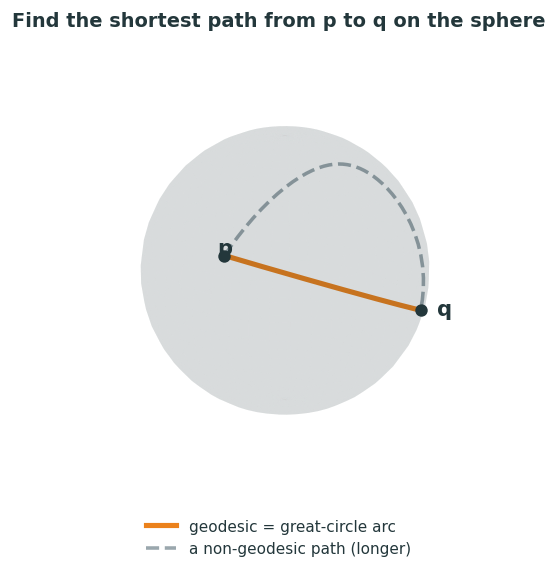

true geodesic length = arccos<p,q> = 1.72924
the drawn detour     length        = 2.40347  (longer)


In [3]:
# ---------- Figure 1: the problem ----------
fig = plt.figure(figsize=(5.6, 5.1)); ax = fig.add_subplot(111, projection="3d")
draw_sphere(ax)
G = great_circle(p_np, q_np)
ax.plot(G[:, 0], G[:, 1], G[:, 2], color=ORANGE, lw=3.2, label="geodesic = great-circle arc")
D = detour_sphere(p_np, q_np)
ax.plot(D[:, 0], D[:, 1], D[:, 2], color=GREY, lw=2.2, ls="--", label="a non-geodesic path (longer)")
mark_pq(ax, p_np, q_np); finish3d(ax)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 0.04), frameon=False, fontsize=9.5)
ax.set_title("Find the shortest path from p to q on the sphere", pad=2)
plt.tight_layout(); plt.show()
print(f"true geodesic length = arccos<p,q> = {Omega:.5f}")
print(f"the drawn detour     length        = {len_sphere(torch.tensor(D)[None])[0].item():.5f}  (longer)")

## 2 · The cross-entropy method (and a gradient polish)

We keep a **policy** $\pi_\theta$: a Gaussian over the interior node coordinates whose samples are
**smooth** (a smoothness prior — geodesics are smooth, so we perturb along a few low-frequency modes
rather than jiggling each node independently). One iteration:

1. **sample** a batch of paths $x^{(b)}\sim\pi_\theta$ (draw coordinates, project to the surface);
2. **score** each by its energy $E$;
3. keep the **elite** — the shortest $\rho\%$;
4. **refit** $\pi_\theta$ to the elite ($\mu\leftarrow\operatorname{mean}$, $\sigma$ annealed) and repeat.

Step 4 *is* the "cross-entropy" step — matching the policy to the elite is minimising cross-entropy to
the elite indicator, which for a Gaussian is just moment matching.

**Then a polish.** The cross-entropy method is *gradient-free* and stalls just short of the optimum (near
convergence every elite path looks like the mean). A few steps of gradient descent on the energy — for a
geometer, the discrete **gradient flow of $E$**, which flows any curve toward a geodesic — snap it onto
the closed form. *Search proposes; gradient refines; we verify.*

In [12]:
# ---------- cross-entropy method with SMOOTH proposals (any surface via `project`) ----------
def run_cem(p, q, project, energy_fn, length_fn, K=14, B=700, rho=0.15, iters=48,
            sigma0=0.6, sigma_floor=8e-4, decay=0.92, modes=6, bulge=0.9, seed=1,
            snap=(0, 4, 12, -1)):
    torch.manual_seed(seed); gen = torch.Generator().manual_seed(seed + 7)
    p = torch.as_tensor(p); q = torch.as_tensor(q)
    t = torch.linspace(0, 1, K + 2)[1:-1]
    u = np.cross(p.numpy(), q.numpy()); u = torch.tensor(u / np.linalg.norm(u))
    mu = (1 - t)[:, None] * p[None] + t[:, None] * q[None] + bulge * torch.sin(np.pi * t)[:, None] * u[None]
    kk = torch.arange(1, modes + 1).double()                 # low-frequency sine modes
    Bm = torch.sin(np.pi * t[:, None] * kk[None])
    Bm = Bm / (Bm.pow(2).sum(1, keepdim=True).sqrt() + 1e-12)  # per-node perturbation variance ~ 1
    sigma = sigma0
    keys = ["mupath_len", "mean_len", "best_len", "sigma", "pmin", "pgate", "pmed", "pmax"]
    H = {k: [] for k in keys}; snaps = {}; init = None
    snap_iters = [(iters - 1 if s == -1 else s) for s in snap]
    for it in range(iters):
        Z = torch.randn(B, modes, 3, generator=gen)
        eps = torch.einsum("km,bmc->bkc", Bm, Z)             # smooth perturbations (B,K,3)
        V = mu[None] + sigma * eps
        Y = torch.cat([p.expand(B, 1, 3), project(V), q.expand(B, 1, 3)], dim=1)
        en = energy_fn(Y); ln = length_fn(Y)
        order = torch.argsort(en); n_el = max(1, int(rho * B)); elite = order[:n_el]
        mup = torch.cat([p[None], project(mu), q[None]], 0)[None]
        H["mupath_len"].append(float(length_fn(mup)[0]))
        H["mean_len"].append(ln.mean().item()); H["best_len"].append(ln[order[0]].item())
        H["sigma"].append(float(sigma))
        qs = torch.quantile(ln, torch.tensor([0.0, rho, 0.5, 1.0]))
        H["pmin"].append(qs[0].item()); H["pgate"].append(qs[1].item())
        H["pmed"].append(qs[2].item()); H["pmax"].append(qs[3].item())
        if it in snap_iters:
            snaps[it] = torch.cat([p[None], project(mu), q[None]], 0).detach().numpy()
        if it == 0:
            m = min(B, 55)
            init = dict(Y=Y[:m].detach().numpy(), elite=np.isin(np.arange(m), elite.numpy()))
        mu = V[elite].mean(0); sigma = max(decay * sigma, sigma_floor)   # refit
    return dict(H={k: np.array(v) for k, v in H.items()}, snaps=snaps, init=init,
                mu=mu.detach(), K=K, elite_frac=rho)

def polish(mu, p, q, project, energy_fn, length_fn, steps=300, lr=1.2e-2):
    p = torch.as_tensor(p); q = torch.as_tensor(q)
    W = mu.clone().detach().requires_grad_(True)
    opt = torch.optim.Adam([W], lr=lr); hist = []
    for _ in range(steps):
        Y = torch.cat([p[None], project(W), q[None]], 0)[None]
        loss = energy_fn(Y)[0]; opt.zero_grad(); loss.backward(); opt.step()
        with torch.no_grad():
            Yl = torch.cat([p[None], project(W), q[None]], 0)[None]; hist.append(float(length_fn(Yl)[0]))
    Y = torch.cat([p[None], project(W), q[None]], 0).detach().numpy()
    return Y, np.array(hist)

res = run_cem(p_t, q_t, to_sphere, en_sphere, len_sphere)
L_cem = res["H"]["mupath_len"][-1]
final, poly = polish(res["mu"], p_t, q_t, to_sphere, en_sphere, len_sphere)
L_poly = float(len_sphere(torch.tensor(final)[None])[0])
print(f"cross-entropy search  length = {L_cem:.5f}    (close)")
print(f"after gradient polish length = {L_poly:.6f}")
print(f"target arccos<p,q>            = {Omega:.6f}")
print(f"final error                   = {abs(L_poly - Omega):.2e}")

cross-entropy search  length = 1.78719    (close)
after gradient polish length = 1.729243
target arccos<p,q>            = 1.729243
final error                   = 3.40e-14


## 3 · Watch the search converge

First the raw material — a batch of sampled paths, then the *elite* the method keeps. Then four snapshots
of the policy mean tightening onto the great circle. Then the quantitative story: the two-phase
convergence (search, then polish) down to the closed-form value, and the whole population of sampled paths
collapsing through the elite gate.

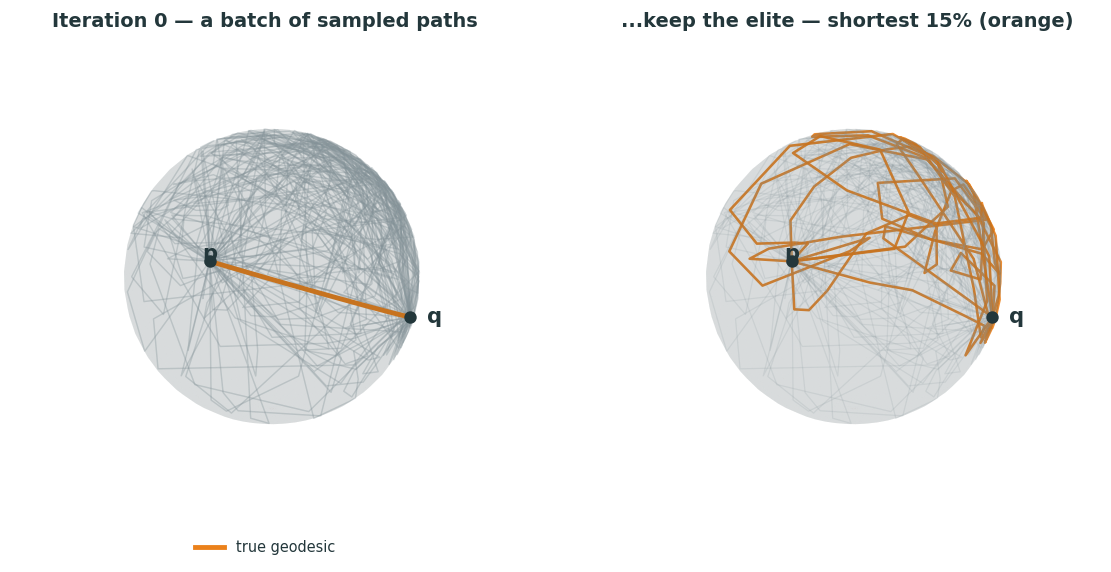

In [13]:
# ---------- Figure 2: initial candidates, and the elite ----------
fig = plt.figure(figsize=(10.2, 4.9)); G = great_circle(p_np, q_np); init = res["init"]
ax = fig.add_subplot(121, projection="3d"); draw_sphere(ax)
for Y in init["Y"]:
    ax.plot(Y[:, 0], Y[:, 1], Y[:, 2], color=GREY, lw=0.9, alpha=0.35)
ax.plot(G[:, 0], G[:, 1], G[:, 2], color=ORANGE, lw=3, label="true geodesic")
mark_pq(ax, p_np, q_np); finish3d(ax)
ax.set_title("Iteration 0 — a batch of sampled paths", pad=2)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 0.02), frameon=False, fontsize=9)
ax = fig.add_subplot(122, projection="3d"); draw_sphere(ax)
for Y, e in zip(init["Y"], init["elite"]):
    if e: ax.plot(Y[:, 0], Y[:, 1], Y[:, 2], color=ORANGE, lw=1.6, alpha=0.9)
    else: ax.plot(Y[:, 0], Y[:, 1], Y[:, 2], color=GREY, lw=0.8, alpha=0.16)
mark_pq(ax, p_np, q_np); finish3d(ax)
ax.set_title(f"...keep the elite — shortest {int(res['elite_frac']*100)}% (orange)", pad=2)
plt.tight_layout(); plt.show()

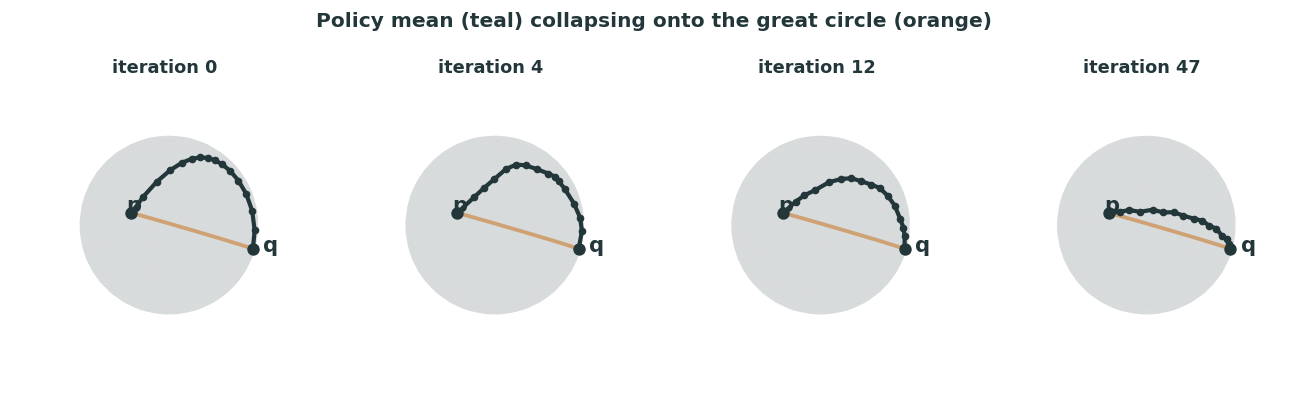

In [14]:
# ---------- Figure 3: the policy mean tightening onto the geodesic ----------
sk = sorted(res["snaps"].keys()); fig = plt.figure(figsize=(11.4, 3.3))
for j, it in enumerate(sk):
    ax = fig.add_subplot(1, len(sk), j + 1, projection="3d"); draw_sphere(ax)
    ax.plot(G[:, 0], G[:, 1], G[:, 2], color=ORANGE, lw=2.4, alpha=0.55)
    P = res["snaps"][it]
    ax.plot(P[:, 0], P[:, 1], P[:, 2], color=TEAL, lw=2.6)
    ax.scatter(P[1:-1, 0], P[1:-1, 1], P[1:-1, 2], color=TEAL, s=14, depthshade=False)
    mark_pq(ax, p_np, q_np); finish3d(ax, elev=22, azim=46)
    ax.set_title(f"iteration {it}", pad=-2, fontsize=11)
fig.suptitle("Policy mean (teal) collapsing onto the great circle (orange)", y=1.02,
             fontsize=12.5, color=TEAL, weight="bold")
plt.tight_layout(); plt.show()

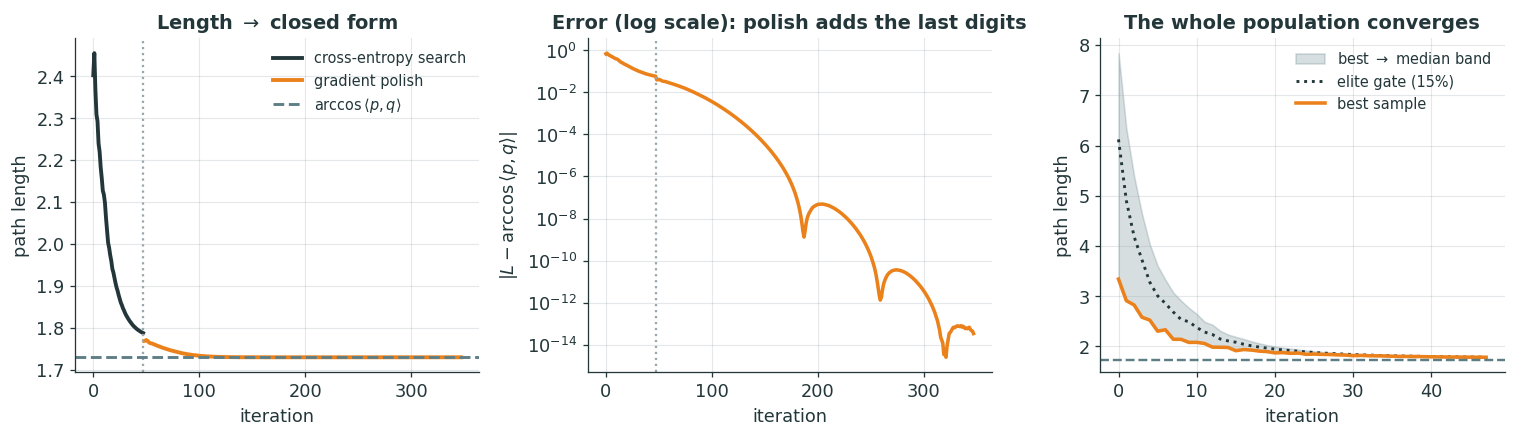

In [15]:
# ---------- Figure 4: convergence curves (search, then polish) ----------
H = res["H"]; nC = len(H["mupath_len"]); xc = np.arange(nC)
xp = nC - 1 + np.arange(1, len(poly) + 1)
comb = np.concatenate([H["mupath_len"], poly]); xcomb = np.concatenate([xc, xp])
fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.9))

ax = axes[0]
ax.plot(xc, H["mupath_len"], color=TEAL, lw=2.4, label="cross-entropy search")
ax.plot(xp, poly, color=ORANGE, lw=2.4, label="gradient polish")
ax.axvline(nC - 1, color=GREY, ls=":", lw=1.4)
ax.axhline(Omega, color=LTEAL, ls="--", lw=1.8, label=r"$\arccos\langle p,q\rangle$")
ax.set_xlabel("iteration"); ax.set_ylabel("path length"); ax.set_title("Length $\\to$ closed form")
ax.legend(frameon=False, fontsize=9); style2d(ax)

ax = axes[1]
ax.semilogy(xcomb, np.abs(comb - Omega) + 1e-16, color=ORANGE, lw=2.2)
ax.axvline(nC - 1, color=GREY, ls=":", lw=1.4)
ax.set_xlabel("iteration"); ax.set_ylabel(r"$|L-\arccos\langle p,q\rangle|$")
ax.set_title("Error (log scale): polish adds the last digits"); style2d(ax)

ax = axes[2]
ax.fill_between(xc, H["pmin"], H["pmed"], color=LTEAL, alpha=0.25, label="best $\\to$ median band")
ax.plot(xc, H["pgate"], color=TEAL, lw=1.8, ls=":", label=f"elite gate ({int(res['elite_frac']*100)}%)")
ax.plot(xc, H["pmin"], color=ORANGE, lw=2.2, label="best sample")
ax.axhline(Omega, color=LTEAL, ls="--", lw=1.5)
ax.set_xlabel("iteration"); ax.set_ylabel("path length")
ax.set_title("The whole population converges"); ax.legend(frameon=False, fontsize=9); style2d(ax)
plt.tight_layout(); plt.show()

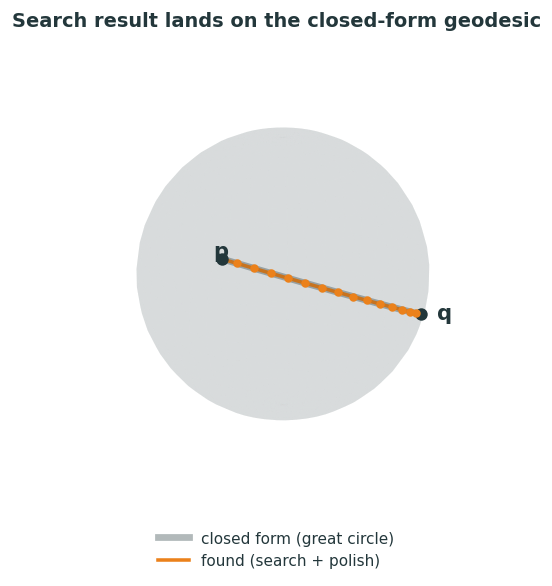

found length 1.729243   vs   arccos<p,q> 1.729243   (relative error 2.0e-14)


In [16]:
# ---------- Figure 5: the found geodesic vs the closed form ----------
fig = plt.figure(figsize=(5.6, 5.2)); ax = fig.add_subplot(111, projection="3d"); draw_sphere(ax)
ax.plot(G[:, 0], G[:, 1], G[:, 2], color=TEAL, lw=4.2, alpha=0.35, label="closed form (great circle)")
ax.plot(final[:, 0], final[:, 1], final[:, 2], color=ORANGE, lw=2.2, label="found (search + polish)")
ax.scatter(final[1:-1, 0], final[1:-1, 1], final[1:-1, 2], color=ORANGE, s=18, depthshade=False)
mark_pq(ax, p_np, q_np); finish3d(ax)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 0.03), frameon=False, fontsize=9.5)
ax.set_title("Search result lands on the closed-form geodesic", pad=2)
plt.tight_layout(); plt.show()
print(f"found length {L_poly:.6f}   vs   arccos<p,q> {Omega:.6f}   "
      f"(relative error {abs(L_poly-Omega)/Omega:.1e})")

### Verify

On the sphere the discrete length is **exact** — a sum of great-circle arcs of points *on* a great circle
is the total arc $\arccos\langle p,q\rangle$, so there is no discretisation error, only the optimiser's,
which the polish drives to $\sim10^{-14}$. Here the "certificate" is the closed form itself. Off the
sphere there is no closed form, so we need a different one.

## 4 · Discovery: a surface with **no closed form**

Take a triaxial ellipsoid $\;x^2/a^2+y^2/b^2+z^2/c^2=1\;$ with $a>b>c$, and the metric it inherits from
$\mathbb R^3$. Its geodesics are governed by **elliptic integrals** — no elementary formula. We change
*nothing* in the algorithm except the surface: nodes are projected radially onto the ellipsoid, and
segment lengths are Euclidean chords (the induced length of a curve in $\mathbb R^3$).

With no formula to compare against, we **certify** instead. A curve on a surface in $\mathbb R^3$ is a
geodesic **iff its acceleration is purely normal** — the tangential part of $\gamma''$ vanishes, i.e.
$\nabla_{\gamma'}\gamma'=0$. So we measure the fraction of the discrete acceleration that is *tangential*:
$\approx 0$ certifies a geodesic; $O(1)$ certifies a detour.

ellipsoid  a,b,c = (1.0, 0.68, 0.46)
found geodesic length (K=16) = 1.35230   (no closed form to compare against)


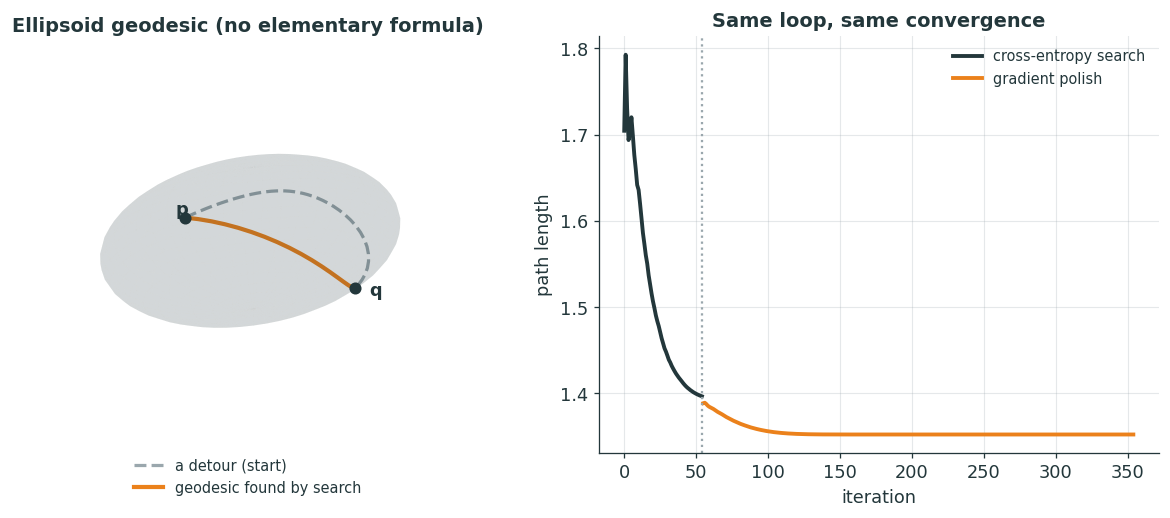

In [17]:
# ---------- geometry on the ellipsoid ----------
ABC = (1.0, 0.68, 0.46)
def to_ellip(V, abc=ABC):
    a, b, c = abc
    s = torch.sqrt((V[..., 0] / a) ** 2 + (V[..., 1] / b) ** 2 + (V[..., 2] / c) ** 2)
    return V / s.unsqueeze(-1)
def seg_chord(Y): return (Y[:, 1:, :] - Y[:, :-1, :]).norm(dim=-1)
def len_ellip(Y): return seg_chord(Y).sum(-1)
def en_ellip(Y):  return (seg_chord(Y) ** 2).sum(-1)
def ellip_np(v, abc=ABC):
    a, b, c = abc
    return v / np.sqrt((v[..., 0] / a) ** 2 + (v[..., 1] / b) ** 2 + (v[..., 2] / c) ** 2)[..., None]

pe = ellip_np(unit_np(np.array([1.0, 0.30, 0.55])))
qe = ellip_np(unit_np(np.array([-0.55, 0.85, -0.35])))
rese = run_cem(pe, qe, to_ellip, en_ellip, len_ellip, K=16, B=800, iters=55, bulge=0.7, seed=3)
finale, polye = polish(rese["mu"], pe, qe, to_ellip, en_ellip, len_ellip)
Le = float(len_ellip(torch.tensor(finale)[None])[0])
print(f"ellipsoid  a,b,c = {ABC}")
print(f"found geodesic length (K=16) = {Le:.5f}   (no closed form to compare against)")

def draw_ellipsoid(ax, abc=ABC, alpha=0.10):
    a, b, c = abc; u = np.linspace(0, 2*np.pi, 46); v = np.linspace(0, np.pi, 24)
    xs = a*np.outer(np.cos(u), np.sin(v)); ys = b*np.outer(np.sin(u), np.sin(v)); zs = c*np.outer(np.ones_like(u), np.cos(v))
    ax.plot_surface(xs, ys, zs, color=TEAL, alpha=alpha, linewidth=0, antialiased=True, shade=False, zorder=0)
def finish_ell(ax, abc=ABC, elev=22, azim=54):
    a, b, c = abc
    ax.set_xlim(-a, a); ax.set_ylim(-b, b); ax.set_zlim(-c, c)
    ax.set_box_aspect((a, b, c)); ax.view_init(elev=elev, azim=azim); ax.set_axis_off()

De = ellip_np(detour_sphere(unit_np(pe), unit_np(qe), bulge=0.6))
fig = plt.figure(figsize=(10.6, 4.6))
ax = fig.add_subplot(121, projection="3d"); draw_ellipsoid(ax)
ax.plot(De[:, 0], De[:, 1], De[:, 2], color=GREY, lw=2, ls="--", label="a detour (start)")
ax.plot(finale[:, 0], finale[:, 1], finale[:, 2], color=ORANGE, lw=2.6, label="geodesic found by search")
ax.scatter(*pe, color=TEAL, s=42, depthshade=False); ax.scatter(*qe, color=TEAL, s=42, depthshade=False)
ax.text(*(pe*1.14), "p", color=TEAL, weight="bold"); ax.text(*(qe*1.14), "q", color=TEAL, weight="bold")
finish_ell(ax); ax.set_title("Ellipsoid geodesic (no elementary formula)", pad=2)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 0.02), frameon=False, fontsize=9)
He = rese["H"]; nCe = len(He["mupath_len"])
ax = fig.add_subplot(122)
ax.plot(np.arange(nCe), He["mupath_len"], color=TEAL, lw=2.4, label="cross-entropy search")
ax.plot(nCe - 1 + np.arange(1, len(polye) + 1), polye, color=ORANGE, lw=2.4, label="gradient polish")
ax.axvline(nCe - 1, color=GREY, ls=":", lw=1.4)
ax.set_xlabel("iteration"); ax.set_ylabel("path length"); ax.set_title("Same loop, same convergence")
ax.legend(frameon=False, fontsize=9); style2d(ax)
plt.tight_layout(); plt.show()

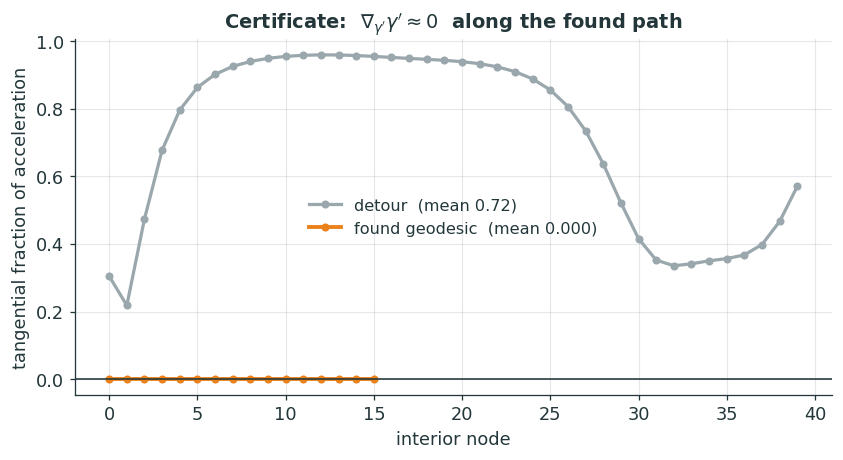

max tangential fraction — detour : 0.959
max tangential fraction — found  : 4.186e-07   (approx 0  =>  a geodesic)


In [22]:
# ---------- Figure 7: certify via the geodesic equation (tangential acceleration) ----------
def tangential_fraction(Y, abc=ABC):
    a, b, c = abc
    acc = Y[:-2] - 2*Y[1:-1] + Y[2:]                          # discrete second difference
    Gn = np.stack([Y[1:-1, 0]/a**2, Y[1:-1, 1]/b**2, Y[1:-1, 2]/c**2], axis=1)
    n = Gn / np.linalg.norm(Gn, axis=1, keepdims=True)        # unit surface normal
    tang = acc - (acc * n).sum(1, keepdims=True) * n          # strip the normal component
    return np.linalg.norm(tang, axis=1) / (np.linalg.norm(acc, axis=1) + 1e-15)

frac_found = tangential_fraction(finale); frac_det = tangential_fraction(De)
fig, ax = plt.subplots(figsize=(7.4, 4.1))
ax.plot(np.arange(len(frac_det)), frac_det, color=GREY, lw=2, marker="o", ms=4,
        label=f"detour  (mean {frac_det.mean():.2f})")
ax.plot(np.arange(len(frac_found)), frac_found, color=ORANGE, lw=2.4, marker="o", ms=4,
        label=f"found geodesic  (mean {frac_found.mean():.3f})")
ax.axhline(0, color=TEAL, lw=1)
ax.set_xlabel("interior node"); ax.set_ylabel("tangential fraction of acceleration")
ax.set_title(r"Certificate:  $\nabla_{\gamma'}\gamma'\approx 0$  along the found path")
ax.legend(frameon=False, fontsize=10); style2d(ax)
plt.tight_layout(); plt.show()
print(f"max tangential fraction — detour : {frac_det.max():.3f}")
print(f"max tangential fraction — found  : {frac_found.max():.3e}   (approx 0  =>  a geodesic)")

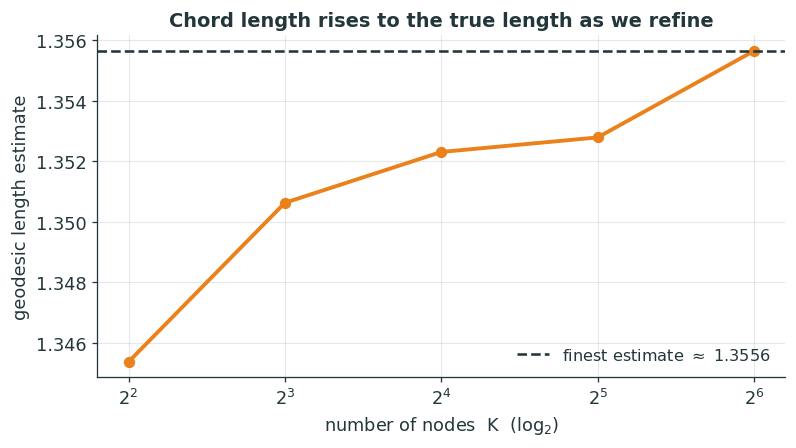

length estimates: [1.3454 1.3506 1.3523 1.3528 1.3556]


In [23]:
# ---------- Figure 8: estimating a length with no closed form (refine the node count) ----------
Ks = [4, 8, 16, 32, 64]; lengths = []
for K in Ks:
    r = run_cem(pe, qe, to_ellip, en_ellip, len_ellip, K=K, B=800, iters=60, bulge=0.7, seed=5)
    Yk, _ = polish(r["mu"], pe, qe, to_ellip, en_ellip, len_ellip, steps=250)
    lengths.append(float(len_ellip(torch.tensor(Yk)[None])[0]))
lengths = np.array(lengths)
fig, ax = plt.subplots(figsize=(7.0, 4.0))
ax.plot(Ks, lengths, color=ORANGE, lw=2.4, marker="o", ms=6)
ax.axhline(lengths[-1], color=TEAL, ls="--", lw=1.6, label=f"finest estimate $\\approx$ {lengths[-1]:.4f}")
ax.set_xscale("log", base=2); ax.set_xlabel("number of nodes  K  (log$_2$)")
ax.set_ylabel("geodesic length estimate")
ax.set_title("Chord length rises to the true length as we refine")
ax.legend(frameon=False, fontsize=10); style2d(ax)
plt.tight_layout(); plt.show()
print("length estimates:", np.round(lengths, 4))

The chord-length underestimate climbs monotonically toward the true length as we add nodes — a
Richardson-style numerical estimate of a number that *has no closed form*. Search **proposed** the
geodesic; the geodesic-equation residual and the refinement study **certified and measured** it. That is
exactly the discipline the rest of the lecture leans on.

## 5 · From elites to gradients: a neural policy (bridge to Part II)

The polish above was gradient descent on the *path itself*. Reinforcement learning's headline family
instead puts the gradient on a **policy**: a network proposes actions and we push its weights *up the
reward gradient*, using no gradient of the reward at all —

$$
\nabla_\theta J=\mathbb E\big[(R-\bar R)\,\nabla_\theta\log\pi_\theta(a)\big].
$$

Here is the smallest version, **REINFORCE**, on the same sphere: a tiny MLP maps a node's position along
the path to a mean point; we sample, score by energy, and update. It is noisier than the cross-entropy
method — honest, and the point: **Part II uses PPO**, a policy gradient with exactly the machinery
(clipping, a value baseline, trust regions) that tames this noise, on the far harder search for *free line
arrangements*.

REINFORCE: mean-path length  final = 1.72972   target = 1.72924


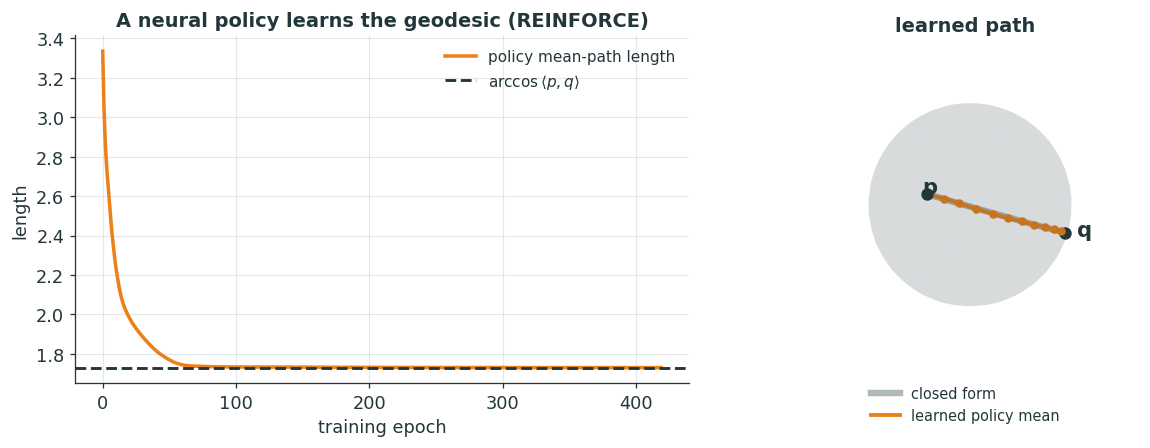

In [24]:
# ---------- a small neural policy trained by REINFORCE ----------
class GeodesicPolicy(nn.Module):
    def __init__(self, K, hidden=64):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(3, hidden), nn.Tanh(),
                                 nn.Linear(hidden, hidden), nn.Tanh(), nn.Linear(hidden, 3))
        self.log_sigma = nn.Parameter(torch.tensor(np.log(0.55)))
    def mean(self, feats): return self.net(feats)

torch.manual_seed(0)
Kp = 10; t = torch.linspace(0, 1, Kp + 2)[1:-1]
feats = torch.stack([t, torch.sin(np.pi * t), torch.cos(np.pi * t)], dim=1)   # positional features
policy = GeodesicPolicy(Kp); opt = torch.optim.Adam(policy.parameters(), lr=6e-3)
Bpg, epochs = 256, 420; hist_len = []
for ep in range(epochs):
    mu = policy.mean(feats); sig = policy.log_sigma.exp()
    eps = torch.randn(Bpg, Kp, 3)
    V = (mu[None] + sig * eps).detach()                       # sampled actions (fixed)
    Y = torch.cat([p_t.expand(Bpg, 1, 3), to_sphere(V), q_t.expand(Bpg, 1, 3)], 1)
    R = (-en_sphere(Y)).detach()
    logp = Normal(mu[None], sig).log_prob(V).sum([1, 2])
    loss = -((R - R.mean()) * logp).mean() - 2e-3 * policy.log_sigma  # +small entropy bonus
    opt.zero_grad(); loss.backward(); opt.step()
    with torch.no_grad():
        mp = torch.cat([p_t[None], to_sphere(policy.mean(feats)), q_t[None]], 0)[None]
        hist_len.append(float(len_sphere(mp)[0]))
print(f"REINFORCE: mean-path length  final = {hist_len[-1]:.5f}   target = {Omega:.5f}")

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.0))
ax = axes[0]
ax.plot(hist_len, color=ORANGE, lw=2.2, label="policy mean-path length")
ax.axhline(Omega, color=TEAL, ls="--", lw=1.8, label=r"$\arccos\langle p,q\rangle$")
ax.set_xlabel("training epoch"); ax.set_ylabel("length")
ax.set_title("A neural policy learns the geodesic (REINFORCE)")
ax.legend(frameon=False, fontsize=9.5); style2d(ax)
axes[1].remove(); ax = fig.add_subplot(122, projection="3d"); draw_sphere(ax)
ax.plot(G[:, 0], G[:, 1], G[:, 2], color=TEAL, lw=4, alpha=0.35, label="closed form")
with torch.no_grad():
    MP = torch.cat([p_t[None], to_sphere(policy.mean(feats)), q_t[None]], 0).numpy()
ax.plot(MP[:, 0], MP[:, 1], MP[:, 2], color=ORANGE, lw=2.4, label="learned policy mean")
ax.scatter(MP[1:-1, 0], MP[1:-1, 1], MP[1:-1, 2], color=ORANGE, s=18, depthshade=False)
mark_pq(ax, p_np, q_np); finish3d(ax)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 0.03), frameon=False, fontsize=9)
ax.set_title("learned path", pad=2)
plt.tight_layout(); plt.show()

## 6 · Recap, and the bridge to Part II

We turned a geometric question into a **game** and let a policy learn to win it:

| ingredient | in this notebook |
|---|---|
| **state** | the path built so far |
| **action** | place the next node on the surface |
| **reward** | $-$(discrete energy); the return is $-E[\gamma]$ |
| **solver** | cross-entropy method (elites) $+$ gradient polish; then REINFORCE (a neural policy) |
| **verification** | closed form on $S^2$; $\nabla_{\gamma'}\gamma'\approx0$ on the ellipsoid |

The lesson is not that RL beats the geodesic ODE — it does not. It is that **the same skeleton**
(build step by step · reward a measurable proxy · keep the good ones · verify exactly) applies wherever
we can *score progress but cannot write the answer down*.

**Part II is that skeleton on a much harder object.** The object is a **line arrangement**; the target is
**freeness**; the reward is the **Saito functional** $\mathfrak S$ (a continuous relaxation of Saito's
criterion, $\mathfrak S=0\iff$ free); the solver is **PPO**, the stabilised policy gradient we just
previewed; and the verification is **exact computation over $\mathbb Q$**. Same idea — *propose by
search, dispose by rigour* — one rung further up the ladder.